## Material Clase Regresion Lineal

#### Regresión Lineal Simple

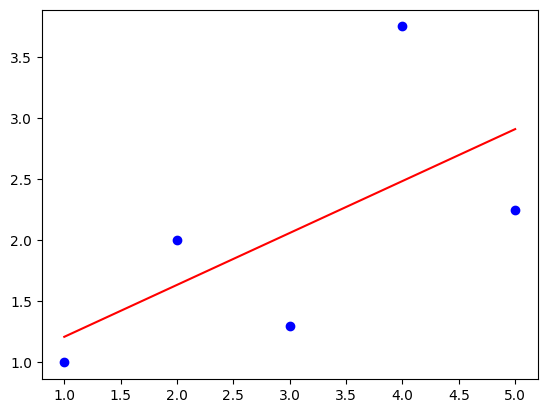

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
# Datos simulados
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 2, 1.3, 3.75, 2.25])
# Creaci´on del modelo
model = LinearRegression()
model.fit(X, y)
# Predicciones
y_pred = model.predict(X)
# Visualizaci´on
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')

#### Regresión Múltiple

In [5]:
# Datos simulados
data = {
'x1': [1, 2, 3, 4, 5],
'x2': [2, 3, 4, 5, 6],
'y': [2.3, 2.9, 4.1, 5.5, 6.8]
}
df = pd.DataFrame(data)
X = df[['x1', 'x2']]
y = df['y']
# Creaci´on del modelo
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [6]:
# Predicciones
y_pred = model.predict(X)
# Resultados
print(f'Intercepto: {model.intercept_}')
print(f'Coeficientes: {model.coef_}')

Intercepto: 0.2599999999999989
Coeficientes: [0.58 0.58]


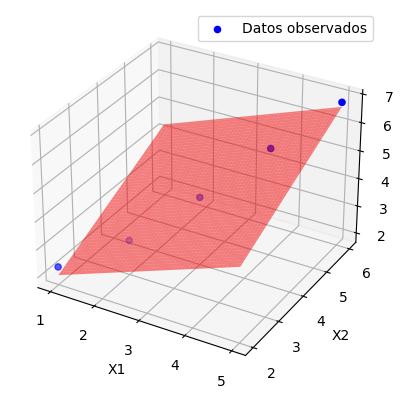

In [7]:
# Creación de la gráfica
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Puntos observados
ax.scatter(df['x1'], df['x2'], df['y'], color='blue', label='Datos observados')

# Superficie de predicción
x_surf, y_surf = np.meshgrid(np.linspace(df['x1'].min(), df['x1'].max(), 100),
                             np.linspace(df['x2'].min(), df['x2'].max(), 100))
z_surf = model.intercept_ + model.coef_[0] * x_surf + model.coef_[1] * y_surf
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.5)

# Etiquetas y leyenda
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.legend()

plt.show()

### Ejemplo Evaluación del Modelo de Regresión Lineal

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression
from scipy import stats

# Generando datos sinteticos
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=3, noise=0.1)

# Ajuste del modelo de regresi´on lineal
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# Calculo de MSE y R^2
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f'MSE: {mse:.2f}, R^2: {r2:.2f}')

MSE: 0.01, R^2: 1.00


### Pruebas de significancia

In [13]:
# Pruebas de significancia de los coeficientes usando t-test
n, p = X.shape
X_with_intercept = np.column_stack((np.ones(n), X))
se_beta = np.sqrt(np.diagonal(np.linalg.inv(X_with_intercept.T @ X_with_intercept) * mse))
t_stats = model.coef_ / se_beta[1:]
p_values = [2 * (1 - stats.t.cdf(np.abs(t), df=n-p-1)) for t in t_stats]

print(f'Coeficientes: {model.coef_}')
print(f'P-valores: {p_values}')

Coeficientes: [28.2045949  75.05077568 17.75449804]
P-valores: [0.0, 0.0, 0.0]


### Ejemplo Evaluación del Modelo de Regresión Multiple

In [14]:
# Generando datos de ejemplo y ajustando un modelo para demostración
X_multiple, y_multiple = make_regression(n_samples=100, n_features=3, noise=0.1)
model = LinearRegression().fit(X_multiple, y_multiple)
y_pred_multiple = model.predict(X_multiple)

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Calculation of evaluation metrics
mse = mean_squared_error(y_multiple, y_pred_multiple)
mae = mean_absolute_error(y_multiple, y_pred_multiple)
r2 = r2_score(y_multiple, y_pred_multiple)
# Creating a DataFrame for the evaluation metrics
evaluation_metrics = pd.DataFrame({
'Metric': ['Mean Squared Error', 'Mean Absolute Error', 'R^2 Score'],
'Value': [mse, mae, r2]
})

print(evaluation_metrics)

                Metric     Value
0   Mean Squared Error  0.009430
1  Mean Absolute Error  0.081271
2            R^2 Score  0.999998


### Multicolinealidad

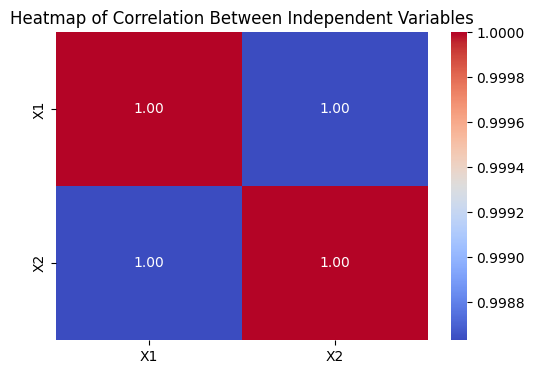

  feature         VIF
0      X1  370.099223
1      X2  370.099223


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

# Generando datos sintéticos con multicolinealidad
np.random.seed(42)
X1 = np.random.normal(0, 1, 100)
X2 = 2 * X1 + np.random.normal(0, 0.1, 100)  # Alta correlación con X1
y = 3 + 2 * X1 + np.random.normal(0, 1, 100)
df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

# Calculando la matriz de correlación
correlation_matrix = df[['X1', 'X2']].corr()

# Visualizando la matriz de correlación como un heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Correlation Between Independent Variables')
plt.show()

# Ajustando un modelo de regresión lineal
X = df[['X1', 'X2']]
model = LinearRegression().fit(X, df['y'])

# Calculando el Factor de Inflación de la Varianza (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


### Regresión Polinómica

In [18]:
from sklearn.preprocessing import PolynomialFeatures
# Datos simulados
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 4, 9, 16, 25])
# Transformaci´on polin´omica
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
# Creaci´on del modelo
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

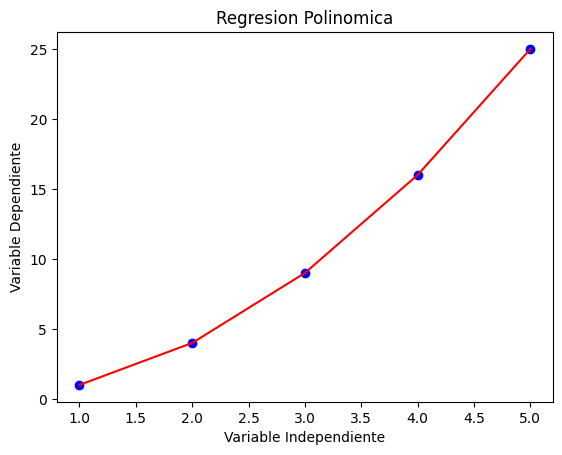

In [19]:
# Predicciones
y_pred = model.predict(X_poly)
# Visualizaci´on
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')
plt.title('Regresion Polinomica')
plt.xlabel('Variable Independiente')
plt.ylabel('Variable Dependiente')
plt.show()

### Sobreajuste usando LOOCV

In [20]:
# Generando datos sintéticos
np.random.seed(42)
X = np.random.normal(0, 1, 100)
y = 3 + 2 * X + np.random.normal(0, 1, 100)  # Corregido: Añadido operador '*'

# Transformando X para ser adecuado para regresiones
X = X.reshape(-1, 1)

# Grados del polinomio a evaluar
degrees = [1, 3, 5, 10]
loocv_errors = []



In [21]:
for degree in degrees:
    # Transformaci´on polin´omica
    poly_features = PolynomialFeatures(degree)
    X_poly = poly_features.fit_transform(X)
    # Ajuste del modelo polin´omico
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    # Calculando los residuos y el hat matrix diagonal (hii)
    residuals = y - y_pred
    H = X_poly @ np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T
    hii = np.diag(H)
    # Calculando LOOCV MSE usando hii
    loocv_mse = np.mean((residuals / (1 - hii))**2)
    loocv_errors.append(loocv_mse)

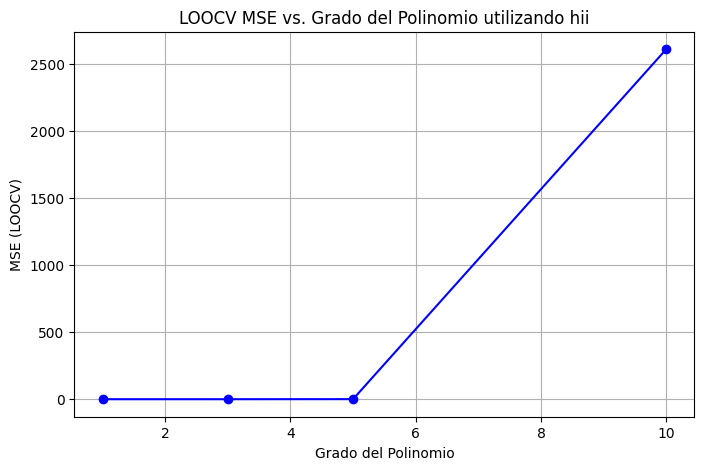

In [22]:
# Grafico de MSE vs. Grado del Polinomio
plt.figure(figsize=(8, 5))
plt.plot(degrees, loocv_errors, marker='o', linestyle='-', color='b')
plt.title('LOOCV MSE vs. Grado del Polinomio utilizando hii')
plt.xlabel('Grado del Polinomio')
plt.ylabel('MSE (LOOCV)')
plt.grid(True)
plt.show()

### Calculo de AIC, BIC y R² Ajustado

In [23]:
# Generando datos sint´eticos con m´as variables para mostrar diferencias
np.random.seed(42)
n = 100 # n´umero de observaciones
# Variables independientes generadas a partir de una distribuci´on normal est´andar
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)
X4 = np.random.normal(0, 1, n)
X5 = np.random.normal(0, 1, n)

In [24]:
# Variable dependiente con ruido a~nadido
y = 3 + 2 * X1 + 0.5 * X2 + np.random.normal(0, 1, n)
# Creando un DataFrame con las variables independientes y dependiente
df = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5, 'y': y})
# Definiendo funciones para calcular AIC y BIC
def calculate_aic(n, mse, k):
    return n * np.log(mse) + 2 * k
def calculate_bic(n, mse, k):
    return n * np.log(mse) + k * np.log(n)

## Modelo Simple

In [25]:
# Modelo simple utilizando solo X1 y X2
X_simple = df[['X1', 'X2']]
model_simple = LinearRegression().fit(X_simple, df['y'])
y_pred_simple = model_simple.predict(X_simple)

# Calculando MSE, AIC, BIC, y R² Ajustado para el modelo simple
mse_simple = mean_squared_error(df['y'], y_pred_simple)
k_simple = X_simple.shape[1] + 1  # incluye el intercepto
aic_simple = calculate_aic(n, mse_simple, k_simple)
bic_simple = calculate_bic(n, mse_simple, k_simple)
r2_adjusted_simple = 1 - (1 - model_simple.score(X_simple, df['y'])) * (n - 1) / (n - k_simple)

# Mostrando los resultados
print(f"MSE: {mse_simple:.4f}")
print(f"AIC: {aic_simple:.4f}")
print(f"BIC: {bic_simple:.4f}")
print(f"R² Ajustado: {r2_adjusted_simple:.4f}")

MSE: 0.8053
AIC: -15.6598
BIC: -7.8443
R² Ajustado: 0.7640


### Modelo utilizando todas las variables

In [26]:
# Modelo complejo utilizando todas las variables
X_complex = df[['X1', 'X2', 'X3', 'X4', 'X5']]
model_complex = LinearRegression().fit(X_complex, df['y'])
y_pred_complex = model_complex.predict(X_complex)

# Calculando MSE, AIC, BIC, y R² Ajustado para el modelo complejo
mse_complex = mean_squared_error(df['y'], y_pred_complex)
k_complex = X_complex.shape[1] + 1  # incluye el intercepto
aic_complex = calculate_aic(n, mse_complex, k_complex)
bic_complex = calculate_bic(n, mse_complex, k_complex)
r2_adjusted_complex = 1 - (1 - model_complex.score(X_complex, df['y'])) * (n - 1) / (n - k_complex)


In [27]:
# Compilando resultados en un DataFrame
results = {
'Model': ['Simple', 'Complex'],
'MSE': [mse_simple, mse_complex],
'AIC': [aic_simple, aic_complex],
'BIC': [bic_simple, bic_complex],
'Adjusted R²': [r2_adjusted_simple, r2_adjusted_complex]
}

df_results = pd.DataFrame(results)
print(df_results)

     Model       MSE        AIC       BIC  Adjusted R²
0   Simple  0.805253 -15.659843 -7.844332     0.763974
1  Complex  0.780066 -12.837637  2.793385     0.764059


### Selección de Variables

In [28]:
from sklearn.datasets import make_regression
from sklearn.feature_selection import SequentialFeatureSelector
# Generando datos sint´eticos
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=10, noise=0.1)

In [29]:
# Modelo de regresión lineal
model = LinearRegression()

# Selección Hacia Adelante utilizando scikit-learn
sfs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward', scoring='r2', cv=5)
sfs.fit(X, y)

# Visualización de los resultados
selected_features = sfs.get_support(indices=True)
print(f'Selección Hacia Adelante: {selected_features}')

Selección Hacia Adelante: [3 4 5 6 9]


In [31]:
# Seleccion Hacia Atras utilizando scikit-learn
sbs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='backward', scoring='r2', cv=5)
sbs.fit(X, y)
# Visualización de los resultados
selected_features_backward = sbs.get_support(indices=True)
print(f'Selecci´on Hacia Atr´as: {selected_features_backward}')

Selecci´on Hacia Atr´as: [3 4 5 6 9]
